# Предсказание сердечно-сосудистых заболеваний

Датасет: [Cardiovascular Disease dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset), файл `cardio_train.csv` (разделитель `;`).
Цель — обучить случайный лес, который по ответам пользователя оценивает вероятность заболевания (`cardio = 1`), и сохранить его для Telegram-бота.

Признаки в исходных данных: `age` (в днях), `gender` (1 — женщина, 2 — мужчина), `height` (см), `weight` (кг),
`ap_hi` / `ap_lo` (верхнее и нижнее давление), `cholesterol` и `gluc` (1 — норма, 2 — выше нормы, 3 — значительно выше),
`smoke`, `alco`, `active` (0/1).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

RANDOM_STATE = 42
DATA_PATH = "data/cardio_train.csv"
MODEL_PATH = "models/model.pkl"

## 1. Загрузка и первый взгляд

In [4]:
df = pd.read_csv(DATA_PATH, sep=";")
print(df.shape)
df.head()

(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [6]:
print("Пропуски по колонкам:")
print(df.isna().sum())
print("\nБаланс классов:")
print(df["cardio"].value_counts(normalize=True))

Пропуски по колонкам:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Баланс классов:
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


## 2. Предобработка

Явных пропусков в датасете нет, но есть физически невозможные значения: давление 11000 или −150, рост 55 см, вес 10 кг.
Такие значения считаем ошибками ввода и превращаем в пропуски, а заполняем их медианой уже внутри пайплайна
(медиана считается только по обучающей выборке, чтобы не было утечки).

Кроме того:
- возраст переводим из дней в полные годы — пользователь бота будет вводить именно годы;
- пол кодируем в `is_male` (0/1);
- если верхнее давление меньше нижнего, считаем, что их перепутали местами, и меняем;
- добавляем индекс массы тела `bmi` — его бот посчитает сам из роста и веса.

In [7]:
df = df.drop(columns="id").drop_duplicates()

df["age"] = (df["age"] / 365.25).astype(int)
df["is_male"] = (df["gender"] == 2).astype(int)
df = df.drop(columns="gender")

# перепутанные местами значения давления
swap = df["ap_lo"] > df["ap_hi"]
df.loc[swap, ["ap_hi", "ap_lo"]] = df.loc[swap, ["ap_lo", "ap_hi"]].values
print(f"Поменяли местами давление в {swap.sum()} строках")

# правдоподобные диапазоны; всё, что вне их, — ошибка ввода
VALID_RANGES = {
    "height": (120, 220),
    "weight": (30, 200),
    "ap_hi": (80, 250),
    "ap_lo": (40, 160),
}
for col, (lo, hi) in VALID_RANGES.items():
    bad = ~df[col].between(lo, hi)
    df.loc[bad, col] = np.nan
    print(f"{col}: {bad.sum()} значений вне [{lo}, {hi}] -> NaN")

Поменяли местами давление в 1234 строках
height: 53 значений вне [120, 220] -> NaN
weight: 7 значений вне [30, 200] -> NaN
ap_hi: 1038 значений вне [80, 250] -> NaN
ap_lo: 454 значений вне [40, 160] -> NaN


In [8]:
def add_bmi(frame: pd.DataFrame) -> pd.DataFrame:
    """ИМТ = вес / рост^2. Эту же функцию (одну строку) повторит бот перед предсказанием."""
    frame = frame.copy()
    frame["bmi"] = frame["weight"] / (frame["height"] / 100) ** 2
    return frame

df = add_bmi(df)

FEATURES = [
    "age", "is_male", "height", "weight", "bmi",
    "ap_hi", "ap_lo", "cholesterol", "gluc",
    "smoke", "alco", "active",
]
TARGET = "cardio"

df[FEATURES].isna().sum()

age               0
is_male           0
height           53
weight            7
bmi              60
ap_hi          1038
ap_lo           454
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
dtype: int64

## 3. Небольшой EDA

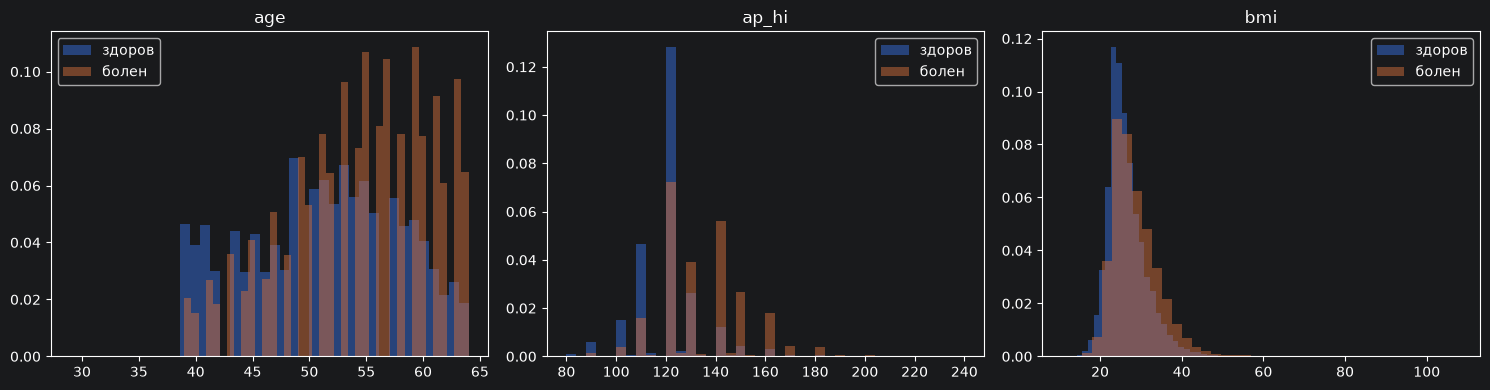

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "ap_hi", "bmi"]):
    for cls, label in [(0, "здоров"), (1, "болен")]:
        ax.hist(df.loc[df[TARGET] == cls, col].dropna(), bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [10]:
df.groupby("cholesterol")[TARGET].mean().rename("доля больных")

cholesterol
1    0.440175
2    0.602157
3    0.765435
Name: доля больных, dtype: float64

## 4. Разбиение на обучение и тест

In [11]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(55980, 12) (13996, 12)


## 5. Обучение случайного леса

Пайплайн: заполнение пропусков медианой → `RandomForestClassifier`. Масштабирование и one-hot не нужны:
дереву всё равно на масштаб, а `cholesterol` и `gluc` — порядковые признаки, их естественно оставить числами 1–3.

Гиперпараметры подбираем случайным поиском с 3-кратной кросс-валидацией по ROC-AUC.

In [12]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [6, 8, 10, 12, 16, None],
    "model__min_samples_leaf": [1, 5, 10, 20, 50],
    "model__max_features": ["sqrt", 0.5],
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Лучшие параметры:", search.best_params_)
print(f"ROC-AUC на кросс-валидации: {search.best_score_:.4f}")
best_model = search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Лучшие параметры: {'model__n_estimators': 500, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 10}
ROC-AUC на кросс-валидации: 0.7994


## 6. Оценка на тестовой выборке

In [13]:
proba_test = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, proba_test)
print(f"ROC-AUC на тесте: {test_auc:.4f}")

print(classification_report(y_test, (proba_test >= 0.5).astype(int), target_names=["здоров", "болен"]))

ROC-AUC на тесте: 0.8025
              precision    recall  f1-score   support

      здоров       0.71      0.79      0.75      7001
       болен       0.76      0.68      0.72      6995

    accuracy                           0.73     13996
   macro avg       0.74      0.73      0.73     13996
weighted avg       0.74      0.73      0.73     13996



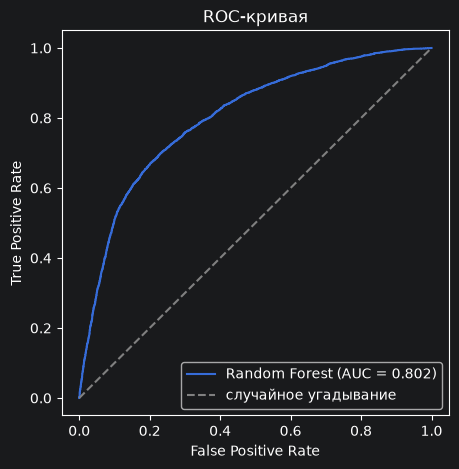

In [14]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="случайное угадывание")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

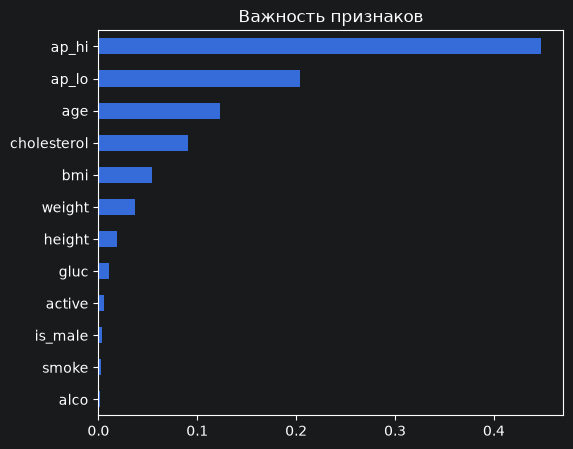

In [15]:
importances = pd.Series(
    best_model.named_steps["model"].feature_importances_, index=FEATURES
).sort_values()
importances.plot.barh(figsize=(6, 5), title="Важность признаков")
plt.show()

## 7. Сохранение модели

Сохраняем не голую модель, а весь пайплайн (с импутером) и вместе с ним список признаков в нужном порядке.
Бот загрузит этот файл, соберёт из ответов пользователя строку `DataFrame` с колонками `FEATURES`
(предварительно посчитав `bmi`) и вызовет `predict_proba`.

In [16]:
artifact = {
    "pipeline": best_model,
    "features": FEATURES,
    "test_roc_auc": test_auc,
    "best_params": search.best_params_,
}
joblib.dump(artifact, MODEL_PATH)
print(f"Сохранено в {MODEL_PATH}")

Сохранено в model.pkl


## 8. Проверка: загрузка и предсказание для одного «пользователя»

In [17]:
loaded = joblib.load(MODEL_PATH)

user = {
    "age": 55, "is_male": 1, "height": 175, "weight": 92,
    "ap_hi": 145, "ap_lo": 95, "cholesterol": 2, "gluc": 1,
    "smoke": 1, "alco": 0, "active": 0,
}
row = add_bmi(pd.DataFrame([user]))[loaded["features"]]
risk = loaded["pipeline"].predict_proba(row)[0, 1]
print(f"Вероятность сердечно-сосудистого заболевания: {risk:.1%}")

Вероятность сердечно-сосудистого заболевания: 83.7%
